In [48]:
import numpy as np
import math
import matplotlib.pyplot as plt

# Exercice 2 : Estimation d'un taux de désintégration (loi de Poisson)

Dans cet exercice, nous étudions le nombre d'événements observés par un détecteur mesurant les désintégrations d'un échantillon radioactif. Ce phénomène est modélisé par une loi de Poisson de paramètre inconnu $\lambda^*$. L'objectif est d'établir les fondements théoriques de cette distribution (moments et cumulants) afin de pouvoir estimer $\lambda^*$ numériquement à partir de mesures indépendantes et d'étudier les probabilités de grandes fluctuations.

## Question 1 : Fonction génératrice des moments et des cumulants

**a) Expression de $M_X(t)$ sous forme de somme**

Par définition en probabilités, l'espérance mathématique d'une fonction $g(X)$ pour une variable aléatoire discrète prenant ses valeurs dans $\mathbb{N}$ est donnée par :
$$\mathbb{E}[g(X)] = \sum_{k=0}^{\infty} g(k) \mathbb{P}(X=k)$$

Ici, la fonction dont on cherche l'espérance est $g(X) = e^{tX}$. L'énoncé nous donne la formule de la loi de Poisson : $\mathbb{P}(X=k) = e^{-\lambda^*} \frac{(\lambda^*)^k}{k!}$.

En substituant ces deux éléments dans la définition de l'espérance, on obtient la somme suivante :
$$M_X(t) = \mathbb{E}[e^{tX}] = \sum_{k=0}^{\infty} e^{tk} \left( e^{-\lambda^*} \frac{(\lambda^*)^k}{k!} \right)$$

**b) Reconnaissance du développement en série**

Pour simplifier cette somme infinie, nous allons réorganiser les termes :

La somme devient alors :
$$M_X(t) = \sum_{k=0}^{\infty} e^{tk} \left( e^{-\lambda^*} \frac{(\lambda^*)^k}{k!} \right) = e^{-\lambda^*} \sum_{k=0}^{\infty} e^{tk} \frac{(\lambda^*)^k}{k!} = e^{-\lambda^*} \sum_{k=0}^{\infty} \frac{(e^t)^k (\lambda^*)^k}{k!} = e^{-\lambda^*} \sum_{k=0}^{\infty} \frac{(\lambda^* e^t)^k}{k!}$$

On reconnaît maintenant exactement la série de Taylor de la fonction exponentielle usuelle, qui s'écrit $\sum_{k=0}^{\infty} \frac{x^k}{k!} = e^x$. 

Ici, notre variable $x$ correspond au bloc $(\lambda^* e^t)$. On remplace donc toute la somme par l'exponentielle correspondante :
$$M_X(t) = e^{-\lambda^*} e^{\lambda^* e^t}$$
0n obtient le résultat final demandé :
$$M_X(t) = e^{\lambda^* e^t - \lambda^*} = e^{\lambda^*(e^t - 1)}$$

**c) Fonction génératrice des cumulants (CGM), moyenne et variance**

La CGM est définie par l'énoncé comme $\kappa_X(t) = \log(M_X(t))$. On trouve alors : 
$$\kappa_X(t) = \log\left(e^{\lambda^*(e^t - 1)}\right) = \lambda^*(e^t - 1) = \lambda^* e^t - \lambda^*$$

Pour trouver la moyenne $\mathbb{E}[X] = \kappa_X'(0)$, on dérive $\kappa_X(t)$ par rapport à $t$ et on a : 
$$\kappa_X'(t) = \lambda^* e^t$$

On évalue cette dérivée en $t=0$ :
$$\mathbb{E}[X] = \kappa_X'(0) = \lambda^* e^0 = \lambda^* \times 1 = \lambda^*$$

Pour trouver la variance $Var(X) = \kappa_X''(0)$, on dérive une seconde fois. 
$$\kappa_X''(t) = \lambda^* e^t$$

Puis on évalue cette dérivée seconde en $t=0$ :
$$Var(X) = \kappa_X''(0) = \lambda^* e^0 = \lambda^*$$


## Question 3 : Estimateur de $\lambda^*$

Nous considérons l'estimateur empirique défini par la moyenne des observations : 
$$\hat{\lambda}(\{X\}_N) = \hat{\lambda}_N = \frac{1}{N}\sum_{i=1}^{N}X_i$$

**1. Moyenne de l'estimateur**

Par linéarité de l'espérance, la moyenne de l'estimateur se calcule ainsi :
$$\mathbb{E}[\hat{\lambda}_N] = \mathbb{E}\left[\frac{1}{N}\sum_{i=1}^{N}X_i\right] = \frac{1}{N}\sum_{i=1}^{N}\mathbb{E}[X_i]$$

Or, d'après la question 1, nous savons que l'espérance d'une variable de Poisson est $\mathbb{E}[X_i] = \lambda^*$. Ainsi :
$$\mathbb{E}[\hat{\lambda}_N] = \frac{1}{N} (N \lambda^*) = \lambda^*$$


**2. Variance de l'estimateur**

Puisque les mesures $X_1, ..., X_N$ sont indépendantes, la variance de leur somme est égale à la somme de leurs variances. on a :
$$Var(\hat{\lambda}_N) = Var\left(\frac{1}{N}\sum_{i=1}^{N}X_i\right) = \frac{1}{N^2}\sum_{i=1}^{N}Var(X_i)$$

Sachant que $Var(X_i) = \lambda^*$, on obtient :
$$Var(\hat{\lambda}_N) = \frac{1}{N^2} (N \lambda^*) = \frac{\lambda^*}{N}$$

**3. Erreur typique**

L'erreur typique correspond à l'écart-type de l'estimateur :
$$\sigma_{\hat{\lambda}} = \sqrt{Var(\hat{\lambda}_N)} = \sqrt{\frac{\lambda^*}{N}} = \frac{\sqrt{\lambda^*}}{\sqrt{N}}$$


## Question 6 : Grandes fluctuations et fonction de taux $I(s)$

D'après le théorème de Cramér, la fonction de taux est définie par[cite: 12, 13] :
$$I(s) = \sup_{t \in \mathbb{R}} \{ts - \kappa_X(t)\}$$

En utilisant l'expression de la fonction génératrice des cumulants trouvée à la question 1, $\kappa_X(t) = \lambda^*(e^t - 1)$ :
$$I(s) = \sup_{t \in \mathbb{R}} \{ts - \lambda^*(e^t - 1)\}$$

Pour trouver le supremum de cette fonction, on dérive l'expression :
$$\frac{d}{dt} \left( ts - \lambda^*(e^t - 1) \right) = 0$$

$$s - \lambda^* e^{t^*} = 0$$

$$e^{t^*} = \frac{s}{\lambda^*}$$

$$t^* = \log\left(\frac{s}{\lambda^*}\right)$$

On substitue cette valeur de $t^*$ dans l'équation initiale pour obtenir l'expression finale de $I(s)$ :
$$I(s) = s \log\left(\frac{s}{\lambda^*}\right) - \lambda^*\left(e^{\log(s/\lambda^*)} - 1\right)$$

$$I(s) = s \log\left(\frac{s}{\lambda^*}\right) - \lambda^*\left(\frac{s}{\lambda^{*}} - 1\right)$$

$$I(s) = s \log\left(\frac{s}{\lambda^*}\right) - s + \lambda^*$$

## Question 7 : Développement autour de la moyenne et lien avec le TCL

Pour faire le lien avec le TCL et étudier les petites fluctuations autour de la moyenne, nous effectuons un développement de Taylor de la fonction de taux $I(s)$ au voisinage de $s = \lambda^*$. 

**1. Calcul des dérivées évaluées en $\lambda^*$**

*   **Ordre 0 :** 
    $$I(\lambda^*) = \lambda^* \log(1) - \lambda^* + \lambda^* = 0$$
*   **Dérivée 1ère :** 
    $$I'(s) = 1 \cdot \log\left(\frac{s}{\lambda^*}\right) + s \cdot \left(\frac{1}{s/\lambda^*} \cdot \frac{1}{\lambda^*}\right) - 1 = \log\left(\frac{s}{\lambda^*}\right) + 1 - 1 = \log\left(\frac{s}{\lambda^*}\right)$$
    Évaluée en $\lambda^*$ : $I'(\lambda^*) = \log(1) = 0$
*   **Dérivée 2ème :** 
    $$I''(s) = \frac{1}{s}$$
    Évaluée en $\lambda^*$ : $I''(\lambda^*) = \frac{1}{\lambda^*}$
*   Dérivée 3ème : $$I'''(s) = -\frac{1}{s^2}$$
    Évaluée en $\lambda^*$ : $I'''(\lambda^*) = -\frac{1}{(\lambda^*)^2}$

**2. Développement de Taylor et approximation Gaussienne**

On peut alors ecrire :
$$I(s) \approx I(\lambda^*) + I'(\lambda^*)(s - \lambda^*) + \frac{1}{2}I''(\lambda^*)(s - \lambda^*)^2 + \frac{1}{6}I'''(\lambda^*)(s - \lambda^*)^3$$

$$I(s) \approx 0 + 0 + \frac{1}{2\lambda^*}(s - \lambda^*)^2 - \frac{1}{6(\lambda^*)^2}(s - \lambda^*)^3$$

Si l'on s'arrête au second ordre pour modéliser le voisinage immédiat de la moyenne, on obtient :
$$I(s) \approx \frac{(s - \lambda^*)^2}{2\lambda^*}$$

En réinjectant ce résultat d'ordre 2 dans la probabilité des grandes déviations $\mathbb{P}(\hat{\lambda}_N \approx s) \approx e^{-NI(s)}$, on trouve :
$$\mathbb{P}(\hat{\lambda}_N \approx s) \approx \exp\left( -N \frac{(s - \lambda^*)^2}{2\lambda^*} \right) = \exp\left( - \frac{(s - \lambda^*)^2}{2(\lambda^*/N)} \right)$$

On reconnaît très exactement le terme exponentiel de la densité d'une loi Normale (Gaussienne)($e^{-\frac{(x-\mu)^2}{2\sigma^2}}$) d'espérance $\mu = \lambda^*$ et de variance $\sigma^2 = \frac{\lambda^*}{N}$. En clair, le TCL revient simplement à approximer notre fonction $I(s)$ par une parabole, à condition de rester très près de la moyenne $\lambda^*$.

**3. Commentaires sur les déviations (terme d'ordre 3)**

Le TCL suggère que la distribution des erreurs est une "cloche" parfaitement symétrique. Cependant, si on s'éloigne de la moyenne, le terme d'ordre 3 $-\frac{(s - \lambda^*)^3}{6(\lambda^*)^2}$ ne peut plus être négligé :
*   **Asymétrie à droite ($s > \lambda^*$) :** L'écart est positif, le terme au cube reste positif. Avec le signe moins devant, cela vient faire baisser la valeur de $I(s)$. Puisque la probabilité est gérée par $e^{-N I(s)}$, une fonction de taux plus faible implique une probabilité exponentiellement plus grande. La vraie courbe s'étale donc plus loin vers la droite que ne le prévoit la Gaussienne.
*   **Asymétrie à gauche ($s < \lambda^*$) :** L'écart est négatif, et un nombre négatif au cube reste négatif. Les signes moins s'annulent, ce qui augmente $I(s)$. La probabilité s'effondre alors beaucoup plus vite.
*   **Conclusion :** L'approximation Gaussienne (le TCL) est une excellente approximation locale pour les petites fluctuations, mais elle sous-estime drastiquement la probabilité d'avoir d'importants pics de radioactivité (grandes déviations à droite) à cause de l'asymétrie inhérente à la loi de Poisson.

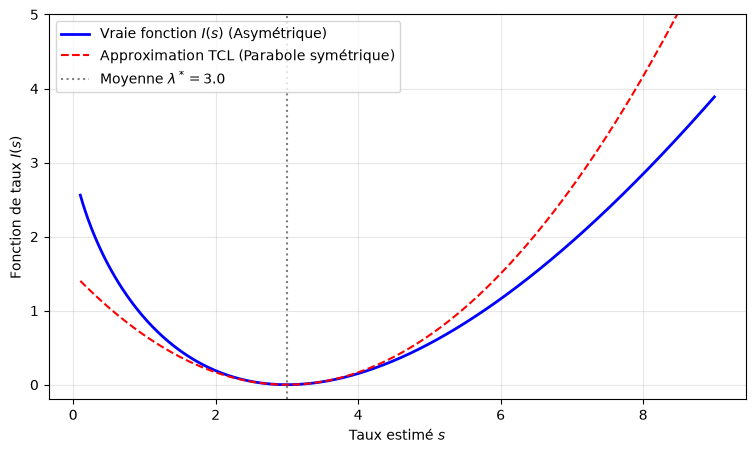

In [49]:
lambda_star = 3.0
s = np.linspace(0.1, 9, 500)
I_exact = s * np.log(s / lambda_star) - s + lambda_star
I_TCL = (s - lambda_star)**2 / (2 * lambda_star)

plt.figure(figsize=(9, 5))
plt.plot(s, I_exact, label='Vraie fonction $I(s)$ (Asymétrique)', color='blue', linewidth=2)
plt.plot(s, I_TCL, label='Approximation TCL (Parabole symétrique)', color='red', linestyle='--')

plt.axvline(lambda_star, color='grey', linestyle=':', label=f'Moyenne $\\lambda^* = {lambda_star}$')

plt.xlabel('Taux estimé $s$')
plt.ylabel('Fonction de taux $I(s)$')
plt.ylim(-0.2, 5)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()